In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import IPython.display as ipd  # To play sound in the notebook
import os
import datetime
import tensorflow as tf
import pyaudio
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from keras.models import load_model
from pydub import AudioSegment, effects
import noisereduce as nr
import wave
from array import array
import struct
import time

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
EMOTIONS = {
    0: 'neutral',
    1: 'calm',
    2: 'happy',
    3: 'sad',
    4: 'angry',
    5: 'fearful',
    6: 'disgust',
    7: 'suprised'
}
COLORS = [
    'gainsboro', 'blue', 'green', 'yellow', 'red', 'darkred', 'peru',
    'lightpink'
]
emo_list = list(EMOTIONS.values())
max_length = 228864
sr = 48000
frame_length = 2048
hop_length = 512

In [3]:
def extract_features(audio):

    scaler = StandardScaler()

    # Initialize data lists
    rms = []
    mfcc = []
    mel = []

    # Fetch the sample rate.
    # rawsound, sr = librosa.load(path=path, duration=3, offset=0.2)
    # sr (the sample rate) is used for librosa's MFCCs. '_' is irrelevant.
    # Load the audio file.
    rawsound = AudioSegment.from_file(audio)
    # rawsound = AudioSegment(data)
    # Normalize the audio to +5.0 dBFS.
    normalizedsound = effects.normalize(rawsound, headroom=5.0)
    # Transform the normalized audio to np.array of samples.
    normal_audio = np.array(normalizedsound.get_array_of_samples(),
                            dtype='float32')
    # Trim silence from the beginning and the end.
    trimmed_audio, index = librosa.effects.trim(y=normal_audio, top_db=30)
    # print(len(trimmed_audio))
    # Pad for duration equalization.
    print(len(trimmed_audio))
    padded_audio = np.pad(trimmed_audio, (0, max_length - len(trimmed_audio)),
                          'constant')
    # Noise reduction.
    final_audio = nr.reduce_noise(y=padded_audio, sr=sr)  #updated 03/03/22

    # Features extraction
    f1 = librosa.feature.rms(
        y=final_audio, frame_length=frame_length,
        hop_length=hop_length).T  # Energy - Root Mean Square

    f3 = librosa.feature.mfcc(y=final_audio,
                              sr=sr,
                              n_mfcc=40,
                              hop_length=hop_length).T  # MFCC

    f6 = librosa.feature.melspectrogram(y=final_audio,
                                        n_fft=frame_length,
                                        hop_length=hop_length).T

    # Filling the data lists

    rms.append(scaler.fit_transform(f1))

    mfcc.append(scaler.fit_transform(f3))

    mel.append(scaler.fit_transform(f6))
    f_rms = np.asarray(rms)

    f_mfccs = np.asarray(mfcc)

    f_mel = np.asarray(mel)
    # Concatenating all features to 'X' variable.
    features = np.concatenate((f_rms, f_mfccs, f_mel), axis=2)
    return features

In [4]:
def emotion(audio):
    x = extract_features(audio)  # 'output.wav' file preprocessing.
    predictions = model.predict(x, use_multiprocessing=True)
    pred_list = list(predictions)
    pred_np = np.squeeze(np.array(pred_list).tolist(),
                         axis=0)  # Get rid of 'array' & 'dtype' statments.
    total_predictions.append(pred_np)

    max_emo = np.argmax(predictions)
    print('max emotion:', EMOTIONS.get(max_emo))
    ax.clear()
    ax.bar(emo_list, pred_np, color=COLORS)
    ax.title.set_text(EMOTIONS.get(max_emo))
    fig.canvas.draw()

In [4]:
model = load_model('Models/LSTM_3F_2.hdf5')

Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



2022-07-22 01:41:31.306095: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-07-22 01:41:31.306391: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
def silence(data):
    return sum(data) / len(data) < 100

In [7]:
FORMAT = pyaudio.paInt16
CHANNELS = 1
RATE = 48000
CHUNK = 512
RECORD_SECONDS = 4.6
WAVE_OUTPUT_FILENAME = "recordedFile.wav"
device_index = 2
audio = pyaudio.PyAudio()
total_predictions = []
print("----------------------record device list---------------------")
info = audio.get_host_api_info_by_index(0)
numdevices = info.get('deviceCount')
for i in range(0, numdevices):
    if (audio.get_device_info_by_host_api_device_index(
            0, i).get('maxInputChannels')) > 0:
        print("Input Device id ", i, " - ",
              audio.get_device_info_by_host_api_device_index(0, i).get('name'))

print("-------------------------------------------------------------")

index = int(input())
print("recording via index " + str(index))

stream = audio.open(format=FORMAT,
                    channels=CHANNELS,
                    rate=RATE,
                    input=True,
                    input_device_index=index,
                    frames_per_buffer=CHUNK)
try:
    while True:
        print("recording started")
        Recordframes = []

        for i in range(0, int(RATE / CHUNK * RECORD_SECONDS)):
            data = stream.read(CHUNK, exception_on_overflow=False)
            Recordframes.append(data)
        print("recording stopped")
        temp = [j for sub in Recordframes[-3:-1] for j in sub]
        if silence(temp):
            print("Silence Detected !")
            ax.clear()
            ax.title.set_text("Silence")
            fig.canvas.draw()
        else:

            waveFile = wave.open(WAVE_OUTPUT_FILENAME, 'wb')
            waveFile.setnchannels(CHANNELS)
            waveFile.setsampwidth(audio.get_sample_size(FORMAT))
            waveFile.setframerate(RATE)
            waveFile.writeframes(b''.join(Recordframes))
            waveFile.close()
            x = extract_features(WAVE_OUTPUT_FILENAME)
            predictions = model.predict(x, use_multiprocessing=True)
            pred_list = list(predictions)
            pred_np = np.squeeze(np.array(pred_list).tolist(), axis=0)
            total_predictions.append(pred_np)

            max_emo = np.argmax(predictions)
            print('max emotion:', EMOTIONS.get(max_emo))
            ax.clear()
            ax.bar(emo_list, pred_np, color=COLORS)
            ax.title.set_text(EMOTIONS.get(max_emo))
            fig.canvas.draw()
except KeyboardInterrupt:
    stream.stop_stream()
    stream.close()
    audio.terminate()

----------------------record device list---------------------
Input Device id  0  -  MacBook Pro Microphone
Input Device id  2  -  Kishan’s AirPods Pro 🦁
Input Device id  4  -  Microsoft Teams Audio
-------------------------------------------------------------


 2


recording via index 2
recording started
recording stopped
197632


2022-07-22 01:41:49.186461: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2022-07-22 01:41:49.398492: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-22 01:41:49.485978: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-22 01:41:50.199853: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


max emotion: disgust
recording started
recording stopped
201216
max emotion: sad
recording started
recording stopped
163840
max emotion: angry
recording started
recording stopped
217600
max emotion: neutral
recording started
recording stopped
220672
max emotion: happy
recording started
recording stopped
215552
max emotion: happy
recording started
recording stopped
200704
max emotion: angry
recording started
recording stopped
206848
max emotion: suprised
recording started
recording stopped
203264
max emotion: angry
recording started
recording stopped
163840
max emotion: disgust
recording started
recording stopped
215040
max emotion: sad
recording started
recording stopped
159232
max emotion: suprised
recording started
recording stopped
219648
max emotion: fearful
recording started
recording stopped
220160
max emotion: calm
recording started
recording stopped
204800
max emotion: angry
recording started
recording stopped
220160
max emotion: fearful
recording started
recording stopped
2206

In [ ]:
stream.stop_stream()
stream.close()
p.terminate()

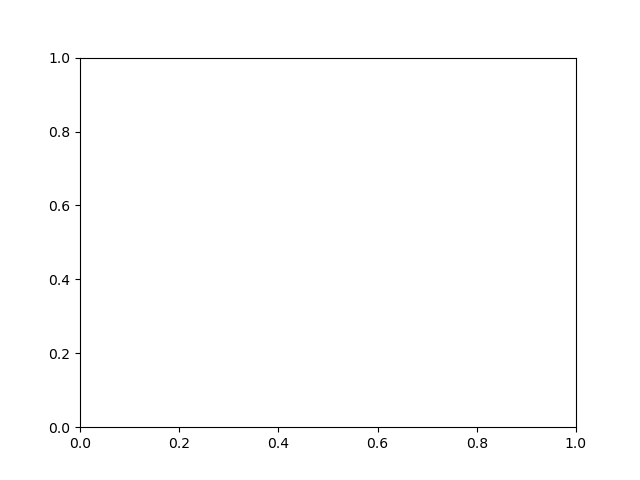

In [6]:
%matplotlib widget
plt.rcParams['animation.html'] = 'jshtml'
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

In [26]:
emotion("recordedFile.wav")

108032
max emotion: neutral
